In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/anomalydetectiondatasetucf/ReadMe_Anomaly_Detection.txt
/kaggle/input/anomalydetectiondatasetucf/Temporal_Anomaly_Annotation_for_Testing_Videos.txt
/kaggle/input/anomalydetectiondatasetucf/UCF_Crimes_Instruction.docx
/kaggle/input/anomalydetectiondatasetucf/Anomaly_Train.txt
/kaggle/input/anomalydetectiondatasetucf/Normal_Train_Inception.txt
/kaggle/input/anomalydetectiondatasetucf/Anomaly_Test.txt
/kaggle/input/anomalydetectiondatasetucf/Anomaly_Train_New.txt
/kaggle/input/anomalydetectiondatasetucf/Normal_Train.txt
/kaggle/input/anomalydetectiondatasetucf/Anomaly_Test_Inception.txt
/kaggle/input/anomalydetectiondatasetucf/weights_L1L2.mat
/kaggle/input/anomalydetectiondatasetucf/model.json
/kaggle/input/anomalydetectiondatasetucf/Anomaly_Train_Inception.txt
/kaggle/input/anomalydetectiondatasetucf/Augmented_Anomaly_Train_Inception.txt
/kaggle/input/anomalydetectiondatasetucf/All_Data/All_Data/Anomaly_Train.txt
/kaggle/input/anomalydetectiondatasetucf/All_Data/All_Data/N

# 0. Import Library

In [2]:
pip install opencv-python torch torchvision tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 34.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [3]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import glob
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# 1. Dataset Loader

In [4]:
class VideoFrameDataset(Dataset):
    def __init__(self, video_dir, transform=None, max_frames=300):
        self.video_paths = [os.path.join(video_dir, f) for f in os.listdir(video_dir) if f.endswith(('.mp4', '.avi'))]
        self.transform = transform
        self.max_frames = max_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        frame_count = 0

        while cap.isOpened() and frame_count < self.max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
            frame_count += 1
        cap.release()

        return torch.stack(frames)


# 2. Model Configuration

In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),  # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # -> 8x8
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),  # -> 64x64
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)

In [6]:
class LightweightConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: Cukup 2 layer downsampling
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1),   # -> 8 @ 32x32
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # -> 16 @ 16x16
            nn.ReLU(True)
        )
        
        # Decoder: Kebalikan dari encoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1), # -> 8 @ 32x32
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=1, output_padding=1),  # -> 3 @ 64x64
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 3. Train Model

## Configurations

In [7]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = VideoFrameDataset('/kaggle/input/anomalydetectiondatasetucf/Normal_Videos_for_Event_Recognition/Normal_Videos_for_Event_Recognition', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LightweightConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30

## Train

In [8]:
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch in tqdm(train_loader):
        frames = batch[0].to(device)  # [B, T, C, H, W]
        for frame in frames:
            optimizer.zero_grad()
            recon = model(frame)
            loss = criterion(recon, frame)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

100%|██████████| 50/50 [00:45<00:00,  1.09it/s]


Epoch 1, Loss: 0.733665


100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


Epoch 2, Loss: 0.319712


100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


...

Epoch 28, Loss: 0.223171


100%|██████████| 50/50 [00:42<00:00,  1.19it/s]


Epoch 29, Loss: 0.224018


100%|██████████| 50/50 [00:42<00:00,  1.19it/s]

Epoch 30, Loss: 0.221980


# 4. Model Evaluation

## setup path and function

In [9]:
def evaluate_video(video_path, model, criterion, transform, device):
    cap = cv2.VideoCapture(video_path)
    scores = []
    model.eval() 

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = Image.fromarray(frame)
        frame = transform(frame).unsqueeze(0).to(device)
        with torch.no_grad():
            recon = model(frame)
            loss = criterion(recon, frame).item()
            scores.append(loss)
    cap.release()

    if not scores:
        return 0.0
        
    return np.max(scores)

In [10]:
# path untuk video tes normal dan anomali
normal_test_videos = glob.glob('/kaggle/input/anomalydetectiondatasetucf/Normal_Videos_for_Event_Recognition/Normal_Videos_for_Event_Recognition/*.mp4')
# semua video dari semua subfolder Anomaly-Videos
anomaly_test_videos = glob.glob('/kaggle/input/anomalydetectiondatasetucf/Anomaly-Videos-Part-4/Anomaly-Videos-Part-4/Shoplifting/*.mp4')

print(f"Ditemukan {len(normal_test_videos)} video tes normal.")
print(f"Ditemukan {len(anomaly_test_videos)} video tes anomali.")

# Untuk demonstrasi yang lebih cepat, kita bisa batasi jumlah video
# Hapus atau komentari baris ini jika Anda ingin menguji semua video
# normal_test_videos = normal_test_videos[:50]
# anomaly_test_videos = anomaly_test_videos[:50]

print(f"\nMenggunakan {len(normal_test_videos)} video tes normal untuk evaluasi.")
print(f"Menggunakan {len(anomaly_test_videos)} video tes anomali untuk evaluasi.")

Ditemukan 50 video tes normal.
Ditemukan 50 video tes anomali.

Menggunakan 50 video tes normal untuk evaluasi.
Menggunakan 50 video tes anomali untuk evaluasi.


## Evaluations

In [11]:
y_true = []  
y_scores = [] 

print("Mengevaluasi video normal...")
for video_path in tqdm(normal_test_videos):
    anomaly_score = evaluate_video(video_path, model, criterion, transform, device)
    y_scores.append(anomaly_score)
    y_true.append(0) 

print("\nMengevaluasi video anomali...")
for video_path in tqdm(anomaly_test_videos):
    anomaly_score = evaluate_video(video_path, model, criterion, transform, device)
    y_scores.append(anomaly_score)
    y_true.append(1) 

y_true = np.array(y_true)
y_scores = np.array(y_scores)

Mengevaluasi video normal...


100%|██████████| 50/50 [03:16<00:00,  3.93s/it]



Mengevaluasi video anomali...


100%|██████████| 50/50 [07:22<00:00,  8.86s/it]


## Calculate and Visualize AUC-ROC

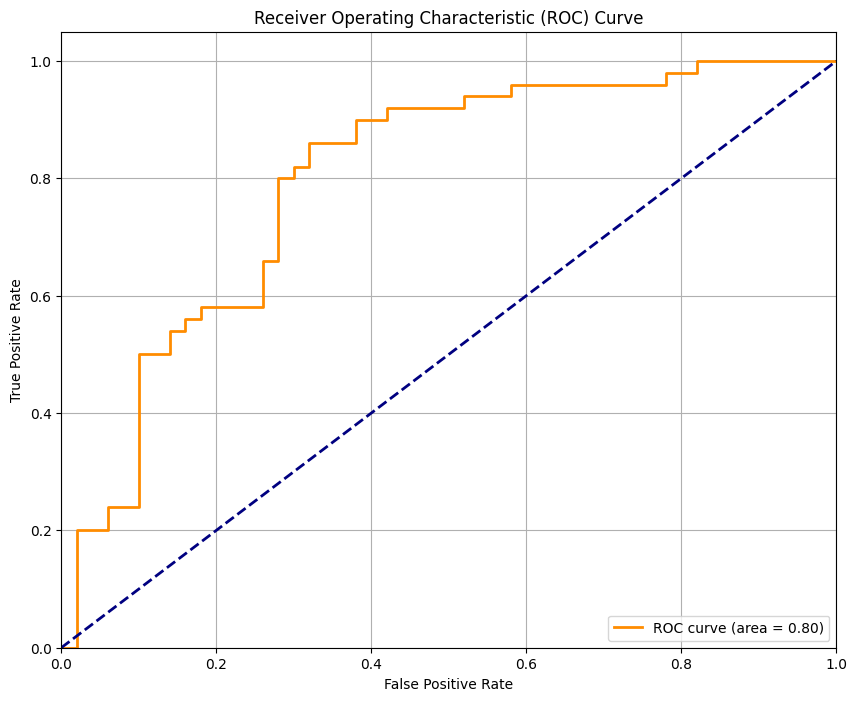


Skor AUC (Area Under Curve): 0.7988


In [12]:
# Hitung ROC curve dan AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\nSkor AUC (Area Under Curve): {roc_auc:.4f}")

## Find Optimal Threshold

In [13]:
J = tpr - fpr
ix = np.argmax(J)
optimal_threshold = thresholds[ix]

print(f"Threshold optimal yang ditemukan: {optimal_threshold:.6f}")
print("Threshold ini memberikan trade-off terbaik antara True Positive Rate dan False Positive Rate.")

Threshold optimal yang ditemukan: 0.002049
Threshold ini memberikan trade-off terbaik antara True Positive Rate dan False Positive Rate.


In [14]:
y_pred = [1 if score >= optimal_threshold else 0 for score in y_scores]

# Hitung metrik evaluasi
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print("\n--- Metrik Evaluasi pada Threshold Optimal ---")
print(f"Akurasi   : {accuracy:.4f}")
print(f"Presisi   : {precision:.4f}")
print(f"Recall (TPR): {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("--------------------------------------------")


--- Metrik Evaluasi pada Threshold Optimal ---
Akurasi   : 0.7700
Presisi   : 0.7288
Recall (TPR): 0.8600
F1-Score  : 0.7890
--------------------------------------------


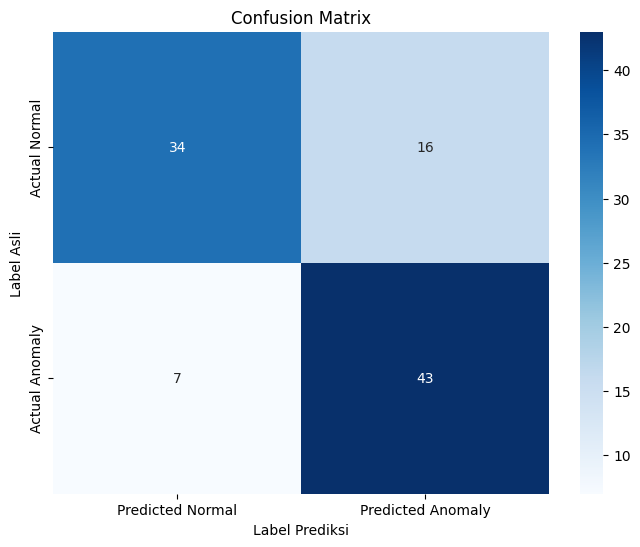

In [15]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.show()

# 5. Save Model

In [16]:
torch.save(model.state_dict(), "autoencoder_ucfcrime.pth")
print("✅ Model berhasil disimpan sebagai autoencoder_ucfcrime.pth")

✅ Model berhasil disimpan sebagai autoencoder_ucfcrime.pth
